<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/klasteryzacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Zadania do samodzielnego wykonania

1.

Proszę pobrać plik customers_mall.csv, zawierający informacje o klientach pewnego centrum handlowego. Pierwsza kolumna przedstawia ich zarobki (w tysiącach), w drugiej zaś znajduje się punktowa ocena wydatków (od 0 do 100) każdego z klientów.  Proszę dokonać klasteryzacji zbioru z użyciem algorytmu k-means. Uzyskane wyniki należy zwizualizować, ocenić i opisać. Wskazane jest zarekomendowanie odpowiedniej ilości klastrów.

2.

W pliku planets.csv mają państwo zbiór 778 spośród ponad 6000 znanych egzoplanet (planet pozasłonecznych) pozyskany z bazy danych NASA (https://exoplanetarchive.ipac.caltech.edu/index.html). Proszę dokonać klasteryzacji tego zbioru kilkoma sposobami, ocenić wyniki za pomocą odpowiednich metryk, wybrać dowolny z wyników i jego rezultaty (czym się charakteryzują klastry).

Poniżej znajduje się opis kolumn do zestawu danych:


         pl_name:        Planet Name,
         pl_orbper:      Orbital Period [days]',
         pl_orbsmax:     Orbit Semi-Major Axis [au]),
         pl_rade:        Planet Radius [Earth Radius],
         pl_masse:       Planet Mass [Earth Mass],
         pl_orbeccen:    Eccentricity,
         pl_eqt:         Equilibrium Temperature [K],
         st_teff:        Stellar Effective Temperature [K],
         st_mass:        Stellar Mass [Solar mass],
         sy_dist:        Distance [pc]

3.

Dla zbioru danych circle.csv proszę, wykorzystując wszystkie poznane do tej pory algorytmy klasteryzacyjne, podjąć kilka prób dopasowania jak najlepszego modelu, za każdym razem oceniając rozwiązanie z użyciem dedykowanych do tego metryk. Który z algorytmów najlepiej radzi sobie z takim układem danych i dlaczego? Proszę przedstawić wyniki również w formie odpowiednich wizualizacji.
___________________________________
## Dodatkowe materiały
* https://matteucci.faculty.polimi.it/Clustering/tutorial_html/cmeans.html
* https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_cmeans.html


   Annual Income  Spending Score
0             15              39
1             15              81
2             16               6
3             16              77
4             17               4


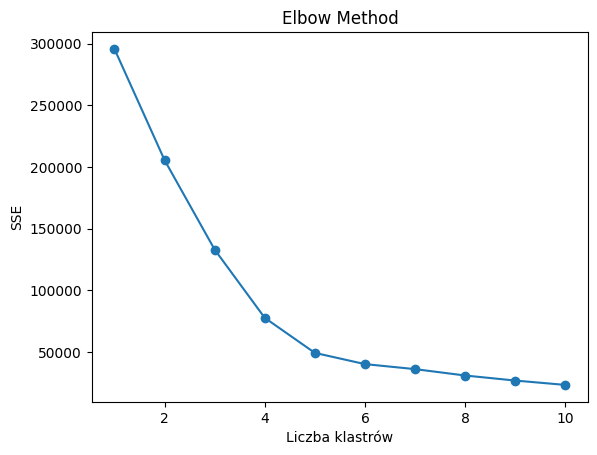

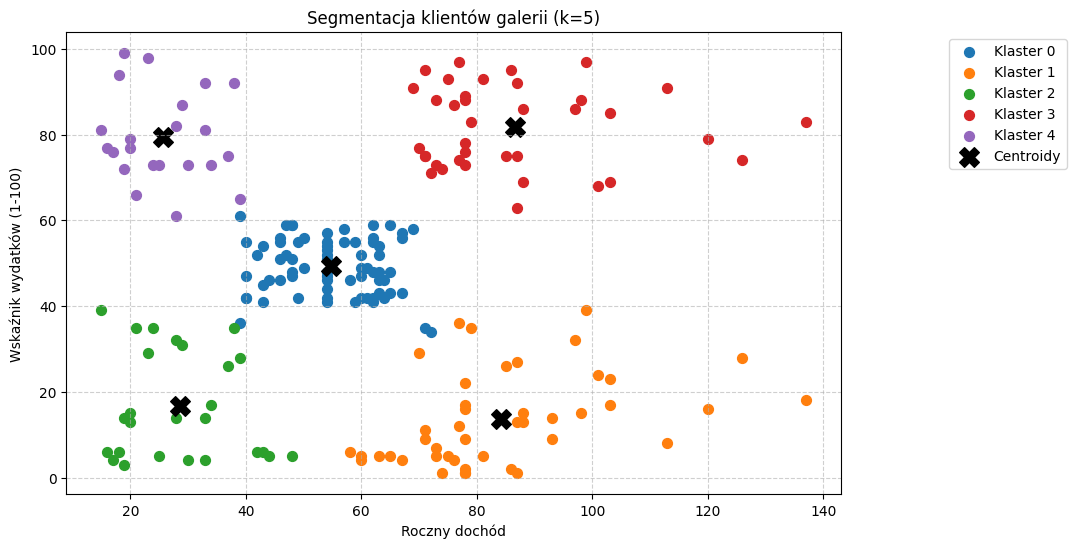


Metryki:
Sihouette Score: 0.544
DB Score : 0.572
CHI Score : 244.650


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn import metrics

data = pd.read_csv('sample_data/customers_mall.csv', sep=';')
print(data.head())
data = data.values

# Wyznaczenie optymalnej liczby klastrów za pomocą Elbow Method
sse = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(data)
  sse.append(kmeans.inertia_)

# Wykres Elbow Method
plt.figure()
plt.plot(range(1,11), sse, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Liczba klastrów')
plt.ylabel('SSE')
plt.show()


kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(data)
print()

plt.figure(figsize=(10, 6))

for i in range(5):
    plt.scatter(data[labels == i, 0], data[labels == i, 1], s=50, label=f'Klaster {i}')

# Dodanie centroidów
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroidy')

plt.title('Segmentacja klientów galerii (k=5)')
plt.xlabel('Roczny dochód')
plt.ylabel('Wskaźnik wydatków (1-100)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nMetryki:")
print("Sihouette Score: %0.3f"
      % metrics.silhouette_score(data, labels))
print("DB Score : %0.3f"
      % metrics.davies_bouldin_score(data, labels))
print("CHI Score : %0.3f"
      % metrics.calinski_harabasz_score(data, labels))


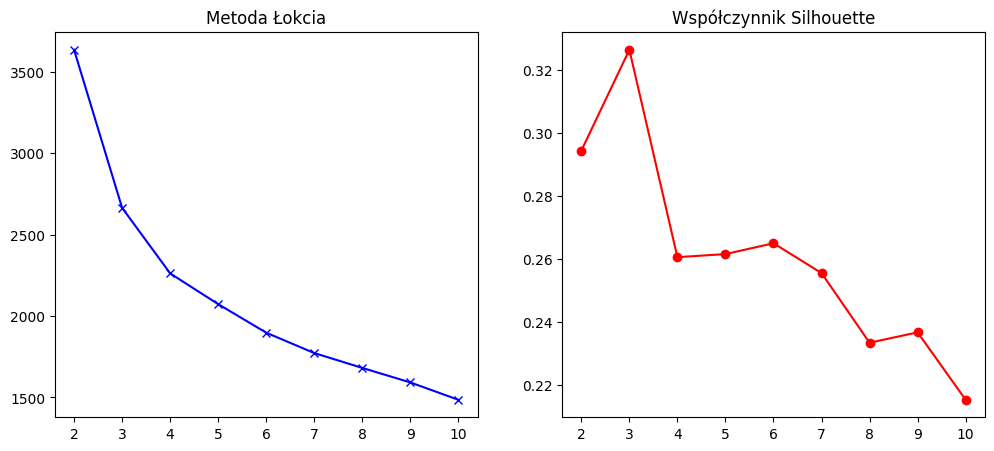

sse [3635.734872827349, 2665.013866458182, 2262.385484420938, 2073.4658517504486, 1898.038392282663, 1772.9689435420514, 1681.5868695502522, 1592.5063435307563, 1485.9687362436277]
sil [np.float64(0.29435961157539803), np.float64(0.32642157927355275), np.float64(0.26053015211699837), np.float64(0.26151288268080924), np.float64(0.2649567932104821), np.float64(0.25549150218854433), np.float64(0.23334782396630263), np.float64(0.2366489480330923), np.float64(0.21522547293784952)]

--- METRYKI DLA: K-Means ---
Silhouette Score: 0.261
Davies-Bouldin Score: 1.360
Calinski-Harabasz Score: 219.769

--- METRYKI DLA: Agglomerative Clustering ---
Silhouette Score: 0.221
Davies-Bouldin Score: 1.482
Calinski-Harabasz Score: 194.514

--- METRYKI DLA: DBSCAN ---
Silhouette Score: 0.246
Davies-Bouldin Score: 2.210
Calinski-Harabasz Score: 77.307
Liczba klastrów: 2
Liczba punktów szumu (outlierów): 8

--- PORÓWNANIE MODELI ---
Adjusted Rand Score (K-Means vs Agglo): 0.725
         pl_orbper  pl_orbsmax 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.decomposition import PCA


df = pd.read_csv('sample_data/planets.csv')
df_numeric = df.drop(columns=['pl_name']).dropna()

scaler = StandardScaler()
X = scaler.fit_transform(df_clean)

sse = []
sil = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sse.append(km.inertia_)
    sil.append(metrics.silhouette_score(X, labels))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(k_range, sse, 'bx-'); plt.title('Metoda Łokcia')
plt.subplot(1, 2, 2); plt.plot(k_range, sil, 'ro-'); plt.title('Współczynnik Silhouette')
plt.show()
print(f"sse {sse}")
print(f"sil {sil}")


k_opt = 4
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(X)
agg = AgglomerativeClustering(n_clusters=k_opt).fit(X)
db = DBSCAN(eps=2.0, min_samples=5).fit(X)

def print_all_metrics(name, data, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"\n--- METRYKI DLA: {name} ---")
    if n_clusters < 2:
        print(f"Model {name} znalazł {n_clusters} klaster. Metryki nie mogą zostać obliczone.")
        return

    print(f"Silhouette Score: {metrics.silhouette_score(data, labels):.3f}")
    print(f"Davies-Bouldin Score: {metrics.davies_bouldin_score(data, labels):.3f}")
    print(f"Calinski-Harabasz Score: {metrics.calinski_harabasz_score(data, labels):.3f}")

    if name == "DBSCAN":
        outliers = list(labels).count(-1)
        print(f"Liczba klastrów: {n_clusters}")
        print(f"Liczba punktów szumu (outlierów): {outliers}")


print_all_metrics("K-Means", X, km.labels_)
print_all_metrics("Agglomerative Clustering", X, agg.labels_)
print_all_metrics("DBSCAN", X, db.labels_)

# metryka porównawcza
print("\n--- PORÓWNANIE MODELI ---")
print("Adjusted Rand Score (K-Means vs Agglo): %0.3f" % metrics.adjusted_rand_score(km.labels_, agg.labels_))


df_clean['cluster'] = km.labels_
print(df_clean.groupby('cluster').mean())


--- WYNIKI WSZYSTKICH PRÓB DOPASOWANIA ---
        Model            Params  Clusters  Silhouette   DB_Score
      K-Means               k=2         2    0.352676   1.185771
      K-Means               k=3         3    0.391574   0.834362
      K-Means               k=4         4    0.379457   0.815896
Agglomerative    linkage='ward'         2    0.338058   1.217078
Agglomerative linkage='average'         2    0.331344   1.229436
Agglomerative  linkage='single'         2    0.113872 170.760374
       DBSCAN  eps=0.1, min_s=5        25   -0.012072   1.481034
       DBSCAN eps=0.15, min_s=5         2    0.088970  77.300360
       DBSCAN  eps=0.2, min_s=3         2    0.113872 170.760374


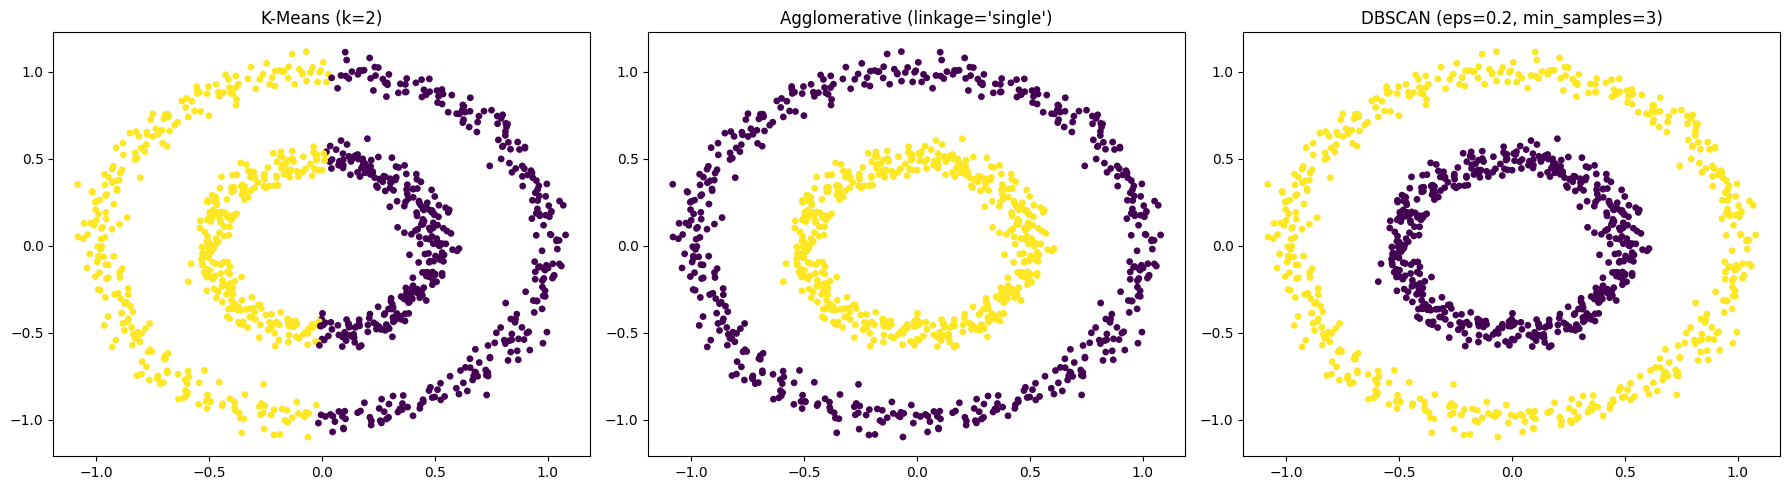


--- MACIERZ ZGODNOŚCI (Adjusted Rand Index) ---
K-Means vs Agglomerative: -0.0009
K-Means vs DBSCAN:        -0.0009
Agglomerative vs DBSCAN:  1.0000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('sample_data/circle.csv')
X = df.iloc[:, :2].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

all_results = []


# Próby K-Means (zmiana liczby klastrów)
kmeans_params = [{'n_clusters': 2}, {'n_clusters': 3}, {'n_clusters': 4}]
for p in kmeans_params:
    km = KMeans(n_clusters=p['n_clusters'], n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    all_results.append({'Model': 'K-Means', 'Params': f"k={p['n_clusters']}", 'Clusters': len(set(labels)), 'Silhouette': sil, 'DB_Score': db})

# Próby Agglomerative Clustering (zmiana metody wiązania, zawsze k=2 dla 2 okręgów)
agg_params = [{'linkage': 'ward'}, {'linkage': 'average'}, {'linkage': 'single'}]
for p in agg_params:
    agg = AgglomerativeClustering(n_clusters=2, linkage=p['linkage'])
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    all_results.append({'Model': 'Agglomerative', 'Params': f"linkage='{p['linkage']}'", 'Clusters': len(set(labels)), 'Silhouette': sil, 'DB_Score': db})

# Próby DBSCAN (zmiana promienia sąsiedztwa i minimalnej liczby punktów)
dbscan_params = [{'eps': 0.1, 'min_samples': 5}, {'eps': 0.15, 'min_samples': 5}, {'eps': 0.2, 'min_samples': 3}]
for p in dbscan_params:
    dbscan = DBSCAN(eps=p['eps'], min_samples=p['min_samples'])
    labels = dbscan.fit_predict(X_scaled)
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil, db = -1.0, np.inf

    all_results.append({'Model': 'DBSCAN', 'Params': f"eps={p['eps']}, min_s={p['min_samples']}", 'Clusters': n_clusters, 'Silhouette': sil, 'DB_Score': db})

# Wyświetlenie tabeli ze wszystkimi próbami
print("--- WYNIKI WSZYSTKICH PRÓB DOPASOWANIA ---")
results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

best_km = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_scaled)
best_agg = AgglomerativeClustering(n_clusters=2, linkage='single').fit_predict(X_scaled)
best_dbscan = DBSCAN(eps=0.2, min_samples=3).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=best_km, cmap='viridis', s=15)
axes[0].set_title("K-Means (k=2)")

axes[1].scatter(X[:, 0], X[:, 1], c=best_agg, cmap='viridis', s=15)
axes[1].set_title("Agglomerative (linkage='single')")

axes[2].scatter(X[:, 0], X[:, 1], c=best_dbscan, cmap='viridis', s=15)
axes[2].set_title("DBSCAN (eps=0.2, min_samples=3)")

plt.tight_layout()
plt.savefig('clustering_results.png')
plt.show()


ari_kmeans_agg = adjusted_rand_score(best_km, best_agg)
ari_kmeans_dbscan = adjusted_rand_score(best_km, best_dbscan)
ari_agg_dbscan = adjusted_rand_score(best_agg, best_dbscan)

print("\n--- MACIERZ ZGODNOŚCI (Adjusted Rand Index) ---")
print(f"K-Means vs Agglomerative: {ari_kmeans_agg:.4f}")
print(f"K-Means vs DBSCAN:        {ari_kmeans_dbscan:.4f}")
print(f"Agglomerative vs DBSCAN:  {ari_agg_dbscan:.4f}")